# 05. cuPF GPU: Jacobian kernel과 sparse solve

04에서는 CPU path가 Jacobian sparse pattern을 한 번 만들고, Newton 반복에서는 `J.valuePtr()`만 갱신한다는 점을 봤다. GPU path도 같은 Newton 구조 위에 있다.

- `V -> Ibus -> mismatch -> Jacobian -> J dx = mismatch -> V update` 순서는 그대로다.
- 바뀌는 것은 Jacobian value fill의 병렬화 방식과 sparse linear solve backend다.
- solve latency는 pybind/native 모두 측정할 수 있다. 다만 `jacobian`, `factorize`, `solve`, `voltage_update`를 분리하려면 native evaluator의 C++ timer가 필요하다.

`case6468rte` 단일 케이스에서는 `initialize_ms`와 `solve_ms`를 나누어 봐야 한다. `initialize_ms`에는 symbolic analysis와 CUDA/cuDSS resource 준비가 들어가고, `solve_ms`에는 Newton 반복 안의 numeric factorization과 triangular solve가 들어간다.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from python.tutorial import tutorial_utils as tu

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.grid'] = False
pd.set_option('display.max_colwidth', 120)

TUTORIAL_CASE = tu.TUTORIAL_LARGE_CASE
RUN_BENCHMARKS = True
REPEATS = 3
WARMUP = 1

def show_cpp(title, text):
    display(Markdown(f"**{title}**\n\n```cpp\n{text}\n```"))

**GPU path에서 분리해서 볼 축**

| 축 | 선택지 | 의미 |
|---|---|---|
| CPU 기준 | `cupf-cpu-klu-native` | CPU fixed-pattern Jacobian + KLU |
| GPU direct solver | `cupf-fp64-cudss-native` | FP64 Jacobian/RHS + cuDSS sparse direct solve |
| GPU Jacobian fill | `Edge`, `EdgeAtomic`, `VertexWarp` | 같은 reduced Jacobian 값을 다른 CUDA work layout으로 채움 |
| 연구용 solver | `cupf-fp64-custom-native` | cuDSS와 비교하는 custom sparse solve path |

핵심 비교는 두 가지다.

- CPU KLU와 GPU solver의 차이는 `factorize`와 `solve` stage에서 나타난다.
- Edge/Vertex 차이는 Jacobian fill stage에서 나타나야 한다. 전체 `solve_ms`에서 차이가 작으면 linear solve가 더 큰 항이라는 뜻이다.

**1. GPU Jacobian fill: 같은 수식, 다른 병렬 layout**

세 kernel은 모두 같은 reduced Jacobian pattern을 채운다. `mapJ11/mapJ12/mapJ21/mapJ22`는 Ybus entry가 Jacobian의 어느 value slot으로 들어가는지 알려주는 scatter map이고, `diagJ**`는 diagonal self term 위치다.

| kind | work assignment | diagonal 처리 | 읽을 포인트 |
|---|---|---|---|
| `Edge` | one thread per Ybus nonzero | diagonal edge에서 cached `Ibus`로 self term 추가 | production path, atomic 없음 |
| `EdgeAtomic` | one thread per Ybus nonzero | edge contribution을 diagonal slot에 `atomicAdd` | 구현은 직관적이지만 diagonal fan-in contention 가능 |
| `VertexWarp` | one warp per bus row | row 안의 nonzero를 lane들이 나눠 읽고 warp reduction | atomic 없음, row degree imbalance 가능 |

아래 코드는 전체를 외우기 위한 것이 아니라, “같은 Jacobian 값을 어떤 parallel unit이 책임지는가”를 확인하기 위한 부분만 잘라 본다.

In [2]:
edge_path = ROOT / 'cuPF/cpp/src/newton_solver/ops/jacobian/fill_jacobian_edge_kernel.hpp'
edge_atomic_path = ROOT / 'cuPF/cpp/src/newton_solver/ops/jacobian/fill_jacobian_edge_atomic_kernel.hpp'
vertex_path = ROOT / 'cuPF/cpp/src/newton_solver/ops/jacobian/fill_jacobian_vertex_warp_kernel.hpp'

pd.DataFrame([
    {'kind': 'Edge', 'source': str(edge_path.relative_to(ROOT))},
    {'kind': 'EdgeAtomic', 'source': str(edge_atomic_path.relative_to(ROOT))},
    {'kind': 'VertexWarp', 'source': str(vertex_path.relative_to(ROOT))},
])

,kind,source
0,Edge,cuPF/cpp/src/newton_solver/ops/jacobian/fill_jacobian_edge_kernel.hpp
1,EdgeAtomic,cuPF/cpp/src/newton_solver/ops/jacobian/fill_jacobian_edge_atomic_kernel.hpp
2,VertexWarp,cuPF/cpp/src/newton_solver/ops/jacobian/fill_jacobian_vertex_warp_kernel.hpp


In [3]:
edge_excerpt = tu.extract_text_between(
    edge_path,
    '    const int32_t tid = blockIdx.x * blockDim.x + threadIdx.x;',
    '    // Only diagonal edges (i == j) add the bus self-term below.',
)
edge_atomic_excerpt = tu.extract_text_between(
    edge_atomic_path,
    '    // Off-diagonal: atomically add this edge',
    '    // Diagonal magnitude blocks:',
)
vertex_excerpt = tu.extract_text_between(
    vertex_path,
    '    // Identify this lane',
    '    if (lane == 0) {',
)
show_cpp('Edge: one Ybus edge maps to Jacobian slots', edge_excerpt)
show_cpp('EdgeAtomic: diagonal slot receives atomic accumulation', edge_atomic_excerpt)
show_cpp('VertexWarp: one warp walks one bus row', vertex_excerpt)

**Edge: one Ybus edge maps to Jacobian slots**

```cpp
const int32_t tid = blockIdx.x * blockDim.x + threadIdx.x;
    if (tid >= total_edges) return;

    const int32_t batch  = tid / nnz_ybus;
    const int32_t k      = tid - batch * nnz_ybus;
    const int32_t y_base = ybus_values_batched ? batch * nnz_ybus : 0;  // Ybus values shared unless batched
    const int32_t v_base = batch * n_bus;
    const int32_t j_base = batch * nnz_J;

    const int32_t i = y_row[k];   // edge source bus
    const int32_t j = y_col[k];   // edge target bus

    const AccumScalar yr     = static_cast<AccumScalar>(y_re[y_base + k]);
    const AccumScalar yi     = static_cast<AccumScalar>(y_im[y_base + k]);
    const AccumScalar vi_re  = static_cast<AccumScalar>(v_re[v_base + i]);
    const AccumScalar vi_im  = static_cast<AccumScalar>(v_im[v_base + i]);
    const AccumScalar vj_re  = static_cast<AccumScalar>(v_re[v_base + j]);
    const AccumScalar vj_im  = static_cast<AccumScalar>(v_im[v_base + j]);
    const AccumScalar vj_abs = static_cast<AccumScalar>(vm[v_base + j]);

    // Shared off-diagonal sensitivity (curr, angle term, magnitude term).
    const EdgeSensitivity<AccumScalar> s =
        compute_edge_sensitivity<AccumScalar>(yr, yi, vi_re, vi_im, vj_re, vj_im, vj_abs);

    // Scatter the off-diagonal contributions (one writer per slot -> plain
    // store, cast to the J storage type). A negative map entry means this edge
    // does not contribute to that sub-block (e.g. PV bus has no Q row).
    if (map11[k] >= 0) J_values[j_base + map11[k]] = static_cast<JScalar>(s.term_va_re);
    if (map21[k] >= 0) J_values[j_base + map21[k]] = static_cast<JScalar>(s.term_va_im);
    if (map12[k] >= 0) J_values[j_base + map12[k]] = static_cast<JScalar>(s.term_vm_re);
    if (map22[k] >= 0) J_values[j_base + map22[k]] = static_cast<JScalar>(s.term_vm_im);
```

**EdgeAtomic: diagonal slot receives atomic accumulation**

```cpp
// Off-diagonal: atomically add this edge's contribution to each sub-block.
    if (map11[k] >= 0) cupf_atomic_add(&J_values[j_base + map11[k]], static_cast<JScalar>(s.term_va_re));
    if (map21[k] >= 0) cupf_atomic_add(&J_values[j_base + map21[k]], static_cast<JScalar>(s.term_va_im));
    if (map12[k] >= 0) cupf_atomic_add(&J_values[j_base + map12[k]], static_cast<JScalar>(s.term_vm_re));
    if (map22[k] >= 0) cupf_atomic_add(&J_values[j_base + map22[k]], static_cast<JScalar>(s.term_vm_im));

    // Diagonal angle blocks: dP/dVa, dQ/dVa gather the negated angle term of
    // every incident edge (the bus row's diagonal is -sum of off-diagonals).
    if (diag11[i] >= 0) cupf_atomic_add(&J_values[j_base + diag11[i]], static_cast<JScalar>(-s.term_va_re));
    if (diag21[i] >= 0) cupf_atomic_add(&J_values[j_base + diag21[i]], static_cast<JScalar>(-s.term_va_im));
```

**VertexWarp: one warp walks one bus row**

```cpp
// Identify this lane's warp -> Jacobian row -> bus, and the batch case.
    constexpr int32_t kWarpSize = 32;
    const int32_t lane = threadIdx.x & (kWarpSize - 1);
    const int32_t warp_in_block = threadIdx.x / kWarpSize;
    const int32_t warps_per_block = blockDim.x / kWarpSize;
    const int32_t row = blockIdx.x * warps_per_block + warp_in_block;
    const int32_t batch = blockIdx.y;
    if (row >= n_rows) return;

    const int32_t bus = pvpq[row];
    const bool has_q_row = diag21[bus] >= 0;   // PQ bus -> has a Q (magnitude) row
    const int32_t y_base = ybus_values_batched ? batch * nnz_ybus : 0;
    const int32_t v_base = batch * n_bus;
    const int32_t j_base = batch * nnz_J;

    // Per-lane partial sums of this bus's diagonal sub-block entries.
    AccumScalar diag11_acc = AccumScalar(0);
    AccumScalar diag21_acc = AccumScalar(0);
    AccumScalar diag12_acc = AccumScalar(0);
    AccumScalar diag22_acc = AccumScalar(0);

    // Lanes stride over the bus's Ybus row (i == bus, j == col).
    for (int32_t k = y_row_ptr[bus] + lane; k < y_row_ptr[bus + 1]; k += kWarpSize) {
        const int32_t col = y_col[k];
        const AccumScalar yr     = static_cast<AccumScalar>(y_re[y_base + k]);
        const AccumScalar yi     = static_cast<AccumScalar>(y_im[y_base + k]);
        const AccumScalar vi_re  = static_cast<AccumScalar>(v_re[v_base + bus]);
        const AccumScalar vi_im  = static_cast<AccumScalar>(v_im[v_base + bus]);
        const AccumScalar vj_re  = static_cast<AccumScalar>(v_re[v_base + col]);
        const AccumScalar vj_im  = static_cast<AccumScalar>(v_im[v_base + col]);
        const AccumScalar vj_abs = static_cast<AccumScalar>(vm[v_base + col]);

        // Shared off-diagonal sensitivity for this edge.
        const EdgeSensitivity<AccumScalar> s =
            compute_edge_sensitivity<AccumScalar>(yr, yi, vi_re, vi_im, vj_re, vj_im, vj_abs);

        // Magnitude diagonal piece for this edge: V_bus-normalized curr.
        const AccumScalar vi_abs = static_cast<AccumScalar>(vm[v_base + bus]);
        AccumScalar diag_vm_re = AccumScalar(0);
        AccumScalar diag_vm_im = AccumScalar(0);
        if (vi_abs > AccumScalar(1.0e-12)) {
            const AccumScalar vni_re = vi_re / vi_abs;
            const AccumScalar vni_im = vi_im / vi_abs;
            diag_vm_re = vni_re * s.curr_re + vni_im * s.curr_im;
            diag_vm_im = vni_im * s.curr_re - vni_re * s.curr_im;
        }

        if (col == bus) {
            // Self edge: contributes only to the magnitude diagonal (the angle
            // diagonal is the negated sum of the off-diagonal angle terms, which
            // the self edge does not add to).
            if (has_q_row) {
                diag12_acc += diag_vm_re + s.term_vm_re;
                diag22_acc += diag_vm_im + s.term_vm_im;
            }
            continue;
        }

        // Off-diagonal edge: angle diagonal gathers -term_va; magnitude diagonal
        // gathers diag_vm.
        diag11_acc += -s.term_va_re;
        if (has_q_row) {
            diag21_acc += -s.term_va_im;
            diag12_acc += diag_vm_re;
            diag22_acc += diag_vm_im;
        }

        // Store this edge's off-diagonal sub-block values (one writer per slot).
        if (map11[k] >= 0) J_values[j_base + map11[k]] = static_cast<JScalar>(s.term_va_re);
        if (map12[k] >= 0) J_values[j_base + map12[k]] = static_cast<JScalar>(s.term_vm_re);
        if (has_q_row) {
            if (map21[k] >= 0) J_values[j_base + map21[k]] = static_cast<JScalar>(s.term_va_im);
            if (map22[k] >= 0) J_values[j_base + map22[k]] = static_cast<JScalar>(s.term_vm_im);
        }
    }

    // Reduce the per-lane diagonal partials across the warp; lane 0 has the sum.
    diag11_acc = warp_reduce_sum(diag11_acc);
    diag21_acc = warp_reduce_sum(diag21_acc);
    diag12_acc = warp_reduce_sum(diag12_acc);
    diag22_acc = warp_reduce_sum(diag22_acc);
```

**2. Dispatch: benchmark variant가 실제 kernel 선택으로 연결되는 위치**

`CudaJacobianOp<double>::run`은 FP64 GPU Jacobian fill의 dispatch 지점이다. benchmark variant의 `cuda_jacobian` 값이 여기서 `Edge`, `EdgeAtomic`, `VertexWarp` 중 하나로 갈라진다.

In [4]:
dispatch_path = ROOT / 'cuPF/cpp/src/newton_solver/ops/jacobian/fill_jacobian_gpu.cu'
show_cpp('CudaJacobianOp<double>::run dispatch', tu.extract_cpp_symbol(dispatch_path, 'CudaJacobianOp<double>::run'))

**CudaJacobianOp<double>::run dispatch**

```cpp
CudaJacobianOp<double>::run(CudaFp64Storage& buf, IterationContext& ctx)
{
    if (kind == CudaJacobianKind::EdgeAtomic) {
        launch_fill_jacobian_edge_atomic<double, double, double>(
            buf.nnz_ybus, buf.nnz_J, buf.n_bus, buf.batch_size,
            buf.ybus_values_batched,
            buf.d_Ybus_re, buf.d_Ybus_im,
            buf.d_Ybus_row, buf.d_Ybus_indices,
            buf.d_V_re, buf.d_V_im, buf.d_Vm,
            buf.d_mapJ11, buf.d_mapJ21, buf.d_mapJ12, buf.d_mapJ22,
            buf.d_diagJ11, buf.d_diagJ21, buf.d_diagJ12, buf.d_diagJ22,
            buf.d_J_values);
    } else if (kind == CudaJacobianKind::VertexWarp) {
        launch_fill_jacobian_vertex_warp<double, double, double>(
            buf.n_pvpq, buf.nnz_ybus, buf.nnz_J, buf.n_bus, buf.batch_size,
            buf.ybus_values_batched,
            buf.d_Ybus_re, buf.d_Ybus_im,
            buf.d_Ybus_indices, buf.d_Ybus_indptr,
            buf.d_V_re, buf.d_V_im, buf.d_Vm,
            buf.d_pvpq,
            buf.d_mapJ11, buf.d_mapJ21, buf.d_mapJ12, buf.d_mapJ22,
            buf.d_diagJ11, buf.d_diagJ21, buf.d_diagJ12, buf.d_diagJ22,
            buf.d_J_values);
    } else {
        launch_fill_jacobian_gpu<double, double, double, double>(
            buf.nnz_ybus, buf.nnz_J, buf.n_bus, buf.batch_size,
            buf.ybus_values_batched,
            // use_cached_ibus=true: the ibus stage ran just before jacobian in the
            // NR loop (and in prepare_adjoint_cache), so d_Ibus is current. Reusing
            // it avoids recomputing the per-diagonal current injection in-kernel.
            true,
            buf.d_Ybus_re, buf.d_Ybus_im,
            buf.d_Ybus_row, buf.d_Ybus_indices, buf.d_Ybus_indptr,
            buf.d_V_re, buf.d_V_im, buf.d_Vm,
            &buf.d_Ibus_re, &buf.d_Ibus_im,
            buf.d_mapJ11, buf.d_mapJ21, buf.d_mapJ12, buf.d_mapJ22,
            buf.d_diagJ11, buf.d_diagJ21, buf.d_diagJ12, buf.d_diagJ22,
            buf.d_J_values);
    }
    dump_cuda_jacobian_if_enabled("jacobian",
                                  ctx.iter,
                                  buf.dimF,
                                  buf.d_J_row_ptr,
                                  buf.d_J_col_idx,
                                  buf.d_J_values,
                                  buf.nnz_J);
}



```

**3. cuDSS: initialize와 solve phase가 갈라지는 이유**

cuDSS는 sparse direct solve를 여러 phase로 나눈다.

| phase | 주로 보이는 위치 | 의미 |
|---|---|---|
| `ANALYSIS` | initialize | sparsity pattern 기반 symbolic analysis |
| `FACTORIZATION` | solve 첫 Newton step | 현재 Jacobian value로 numeric factorization |
| `REFACTORIZATION` | solve 이후 Newton step | 같은 pattern에서 value만 바뀐 경우 재사용 |
| `SOLVE` | solve 매 Newton step | factorized matrix로 `dx` 계산 |

따라서 GPU 결과는 `total_ms` 하나로 보면 안 된다. 단일 케이스 latency에서는 `initialize_ms`가 크게 보일 수 있고, 반복 solve나 batch 시나리오에서는 amortize되는 비용과 매 solve마다 반복되는 비용을 분리해야 한다.

In [5]:
cudss_path = ROOT / 'cuPF/cpp/src/newton_solver/ops/linear_solve/cuda_cudss.cpp'
analysis_excerpt = tu.extract_text_between(
    cudss_path,
    '    // Symbolic analysis can run now',
    '    // Mirror the symbolic analysis',
)
factor_excerpt = tu.extract_cpp_symbol(cudss_path, 'CudaLinearSolveCuDSS<T, Buffers>::factorize')
solve_excerpt = tu.extract_cpp_symbol(cudss_path, 'CudaLinearSolveCuDSS<T, Buffers>::solve')
show_cpp('cuDSS initialize: symbolic analysis', analysis_excerpt)
show_cpp('cuDSS factorize: numeric factorization/refactorization', factor_excerpt)
show_cpp('cuDSS solve: sparse triangular solve', solve_excerpt)

**cuDSS initialize: symbolic analysis**

```cpp
// Symbolic analysis can run now unless this reordering needs matrix values
    // (in that case it is deferred to factorize()).
    if (!cupf_cudss_detail::analysis_requires_matrix_values(cudss_options_)) {
        newton_solver::utils::ScopedTimer timer("NR.initialize.cudss_analyze");
        set_cudss_stream(state_->handle);
        CUDSS_CHECK(cudssExecute(
            state_->handle, CUDSS_PHASE_ANALYSIS,
            state_->config, state_->data,
            state_->jacobian, state_->solution_matrix, state_->rhs_matrix));
        sync_cuda_for_timing();
        state_->analysis_done = true;
    }
```

**cuDSS factorize: numeric factorization/refactorization**

```cpp
CudaLinearSolveCuDSS<T, Buffers>::factorize(Buffers& buf, IterationContext& ctx)
{
    (void)ctx;

    if (buf.dimF <= 0 || buf.d_F.empty() || buf.d_dx.empty()) {
        throw std::runtime_error("CudaLinearSolveCuDSS::factorize: buffers are not prepared");
    }
    if (state_ == nullptr) {
        throw std::runtime_error("CudaLinearSolveCuDSS::factorize: initialize() must be called first");
    }

#ifndef CUPF_ENABLE_CUDSS
    throw std::runtime_error("CudaLinearSolveCuDSS::factorize requires a cuDSS-enabled build");
#else
    ensure_descriptors(buf);

    // Deferred symbolic analysis (value-dependent reordering path).
    if (!state_->analysis_done) {
        newton_solver::utils::ScopedTimer timer("NR.iteration.cudss_analyze");
        set_cudss_stream(state_->handle);
        CUDSS_CHECK(cudssExecute(
            state_->handle, CUDSS_PHASE_ANALYSIS,
            state_->config, state_->data,
            state_->jacobian, state_->solution_matrix, state_->rhs_matrix));
        sync_cuda_for_timing();
        state_->analysis_done = true;
    }

    // First time -> full factorization; afterwards -> refactorization (reuses
    // the symbolic structure, only the numeric values change).
    const bool is_refactorization = state_->factorized;
    const int  phase = is_refactorization ? CUDSS_PHASE_REFACTORIZATION : CUDSS_PHASE_FACTORIZATION;
    set_cudss_stream(state_->handle);
    CUDSS_CHECK(cudssExecute(
        state_->handle, phase,
        state_->config, state_->data,
        state_->jacobian, state_->solution_matrix, state_->rhs_matrix));
    sync_cuda_for_timing();
    state_->factorized = true;
#endif
}



```

**cuDSS solve: sparse triangular solve**

```cpp
CudaLinearSolveCuDSS<T, Buffers>::solve(Buffers& buf, IterationContext& ctx)
{
    if (state_ == nullptr) {
        throw std::runtime_error("CudaLinearSolveCuDSS::solve: initialize() must be called first");
    }
    if (!state_->factorized) {
        throw std::runtime_error("CudaLinearSolveCuDSS::solve: factorize() must be called first");
    }

#ifndef CUPF_ENABLE_CUDSS
    throw std::runtime_error("CudaLinearSolveCuDSS::solve requires a cuDSS-enabled build");
#else
    set_cudss_stream(state_->handle);
    CUDSS_CHECK(cudssExecute(
        state_->handle, CUDSS_PHASE_SOLVE,
        state_->config, state_->data,
        state_->jacobian, state_->solution_matrix, state_->rhs_matrix));
    sync_cuda_for_timing();

    // Debug-only: copy dx back to host and record it.
    if (newton_solver::utils::isDumpEnabled()) {
        const int32_t count = buf_batch_size(buf) * buf.dimF;
        // count is a positive element count; widen to size_t for the host vector.
        std::vector<T> h_dx(static_cast<std::size_t>(count));
        buf.d_dx.copyTo(h_dx.data(), h_dx.size());
        newton_solver::utils::dumpVector("dx", ctx.iter, h_dx);
    }
#endif
}



```

**4. Native benchmark: CPU KLU, cuDSS, custom solver**

성능표는 native evaluator로 만든다. pybind 경로도 end-to-end latency 측정에는 사용할 수 있지만, stage별 timer를 남기지 않는다. native evaluator는 C++ timer가 `timing.csv`에 남기 때문에 Jacobian fill, factorization, solve를 따로 읽을 수 있다.

기본 설정은 `case6468rte`, warmup 1회, repeats 3회다. warmup 없이 첫 GPU solve를 재면 CUDA/cuDSS cold-start 비용이 solve phase에 섞일 수 있으므로, 여기서는 첫 실행을 버리고 반복 측정한다.

In [6]:
display(tu.command_plan_table([
    ('build CPU evaluator', tu.build_eval_command('cpu', jobs=2)),
    ('build GPU cuDSS evaluator', tu.build_eval_command('gpu', jobs=2)),
    ('build GPU custom evaluator', tu.build_eval_command('gpu-custom', jobs=2)),
]))
cpu_build = tu.build_eval('cpu', jobs=2, timeout=2400)
gpu_build = tu.build_eval('gpu', jobs=2, timeout=3600)
custom_build = tu.build_eval('gpu-custom', jobs=2, timeout=3600)
print(tu.command_summary(cpu_build, tail_lines=8))
print(tu.command_summary(gpu_build, tail_lines=8))
print(tu.command_summary(custom_build, tail_lines=8))

,step,command
0,build CPU evaluator,bash benchmark/scripts/build_eval.bash cpu --jobs 2
1,build GPU cuDSS evaluator,bash benchmark/scripts/build_eval.bash gpu --jobs 2
2,build GPU custom evaluator,bash benchmark/scripts/build_eval.bash gpu-custom --jobs 2


$ bash benchmark/scripts/build_eval.bash cpu --jobs 2
[OK] elapsed=0.2s
Consolidate compiler generated dependencies of target _cupf
[100%] Built target _cupf
[ 82%] Built target cupf
Consolidate compiler generated dependencies of target cupf_cpp_evaluate
[100%] Built target cupf_cpp_evaluate
[build_eval] done. artifacts under /workspace/gpu-powerflow-master/cuPF/build/eval-cpu
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-cpu/tests/cupf_cpp_evaluate
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-cpu/_cupf.cpython-310-x86_64-linux-gnu.so
$ bash benchmark/scripts/build_eval.bash gpu --jobs 2
[OK] elapsed=0.3s
Consolidate compiler generated dependencies of target _cupf
[100%] Built target _cupf
[ 86%] Built target cupf
Consolidate compiler generated dependencies of target cupf_cpp_evaluate
[100%] Built target cupf_cpp_evaluate
[build_eval] done. artifacts under /workspace/gpu-powerflow-master/cuPF/build/eval-gpu
[build_eval]   /workspace/gpu-powerflow-mast

In [7]:
variants = [
    'cupf-cpu-klu-native',
    'cupf-fp64-cudss-native',
    'cupf-fp64-cudss-edge-atomic-native',
    'cupf-fp64-cudss-vertex-warp-native',
    'cupf-fp64-custom-native',
]
run_name = tu.timestamp_run_name('tutorial-gpu-native')
display(tu.command_plan_table([
    ('run native GPU comparison', tu.tutorial_benchmark_command(
        variants=variants,
        run_name=run_name,
        cases=[TUTORIAL_CASE],
        repeats=REPEATS,
        warmup=WARMUP,
    )),
]))
if RUN_BENCHMARKS:
    run_dir, command = tu.run_tutorial_benchmark(
        variants=variants,
        run_name=run_name,
        cases=[TUTORIAL_CASE],
        repeats=REPEATS,
        warmup=WARMUP,
        timeout=3600,
    )
    print(tu.command_summary(command, tail_lines=24))
else:
    run_dir = tu.tutorial_output_root()

summary = tu.benchmark_result_table(run_dir)
summary['variant_key'] = summary['variant'].str.replace('-native', '', regex=False)
display(summary[['variant_key', 'status', 'entrypoint', 'linear_solver', 'jacobian', 'initialize_ms', 'solve_ms', 'worst_residual', 'note']])

,step,command
0,run native GPU comparison,/usr/bin/python3 -m python.tests.run_benchmark --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs -...


$ /usr/bin/python3 -m python.tests.run_benchmark --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --run-name tutorial-gpu-native-20260601-152338 --cases case6468rte --repeats 3 --warmup 1 --variants cupf-cpu-klu-native cupf-fp64-cudss-native cupf-fp64-cudss-edge-atomic-native cupf-fp64-cudss-vertex-warp-native cupf-fp64-custom-native
[OK] elapsed=7.9s
[cpp][OK] case=case6468rte repeat=2 init_ms=6.8957 solve_ms=13.7461 mismatch=1.34055e-11 err=1.96009e-13
[cupf-cpu-klu-native] wrote /workspace/gpu-powerflow-master/python/tutorial/_runs/tutorial-gpu-native-20260601-152338/cupf-cpu-klu-native/runs.csv
[cupf-fp64-cudss-native][RUN] /workspace/gpu-powerflow-master/cuPF/build/eval-gpu/tests/cupf_cpp_evaluate --case-root /workspace/gpu-powerflow-master/python/tutorial/_runs/tutorial-gpu-native-20260601-152338/cupf-fp64-cudss-native/dumps --output-dir /tmp/cupf-fp64-cudss-native-p0one080 --backend cuda --compute fp64 --cpu-linear-solver klu --cuda-jacobian edge --cuda-linear

,variant_key,status,entrypoint,linear_solver,jacobian,initialize_ms,solve_ms,worst_residual,note
4,cupf-fp64-custom,ok,native,custom,edge,19.504507,2.439360,1.090898e-11,
1,cupf-fp64-cudss-edge-atomic,ok,native,cudss,edge_atomic,64.973261,2.993561,1.088227e-11,
2,cupf-fp64-cudss,ok,native,cudss,edge,64.983306,2.995591,9.936510e-12,
3,cupf-fp64-cudss-vertex-warp,ok,native,cudss,vertex_warp,64.844807,3.103464,8.352149e-12,
0,cupf-cpu-klu,ok,native,klu,native_fixed_pattern,6.913407,13.628513,1.340550e-11,


,variant_key,initialize_ms,solve_ms,linear_solver,jacobian
4,cupf-fp64-custom,19.505,2.439,custom,edge
1,cupf-fp64-cudss-edge-atomic,64.973,2.994,cudss,edge_atomic
2,cupf-fp64-cudss,64.983,2.996,cudss,edge
3,cupf-fp64-cudss-vertex-warp,64.845,3.103,cudss,vertex_warp
0,cupf-cpu-klu,6.913,13.629,klu,native_fixed_pattern


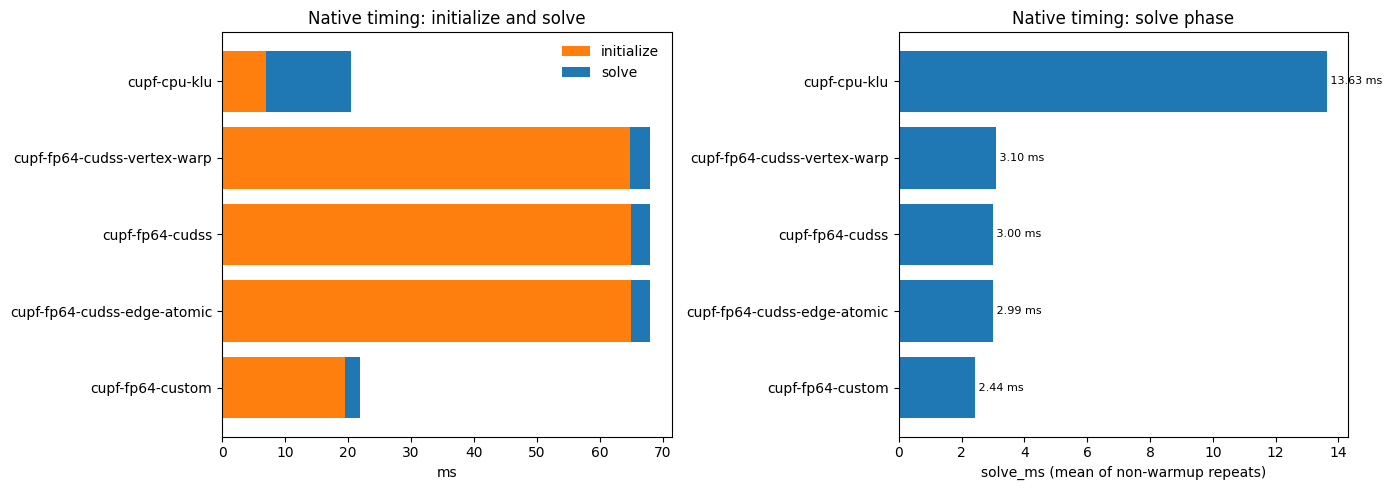

In [8]:
ok = tu.successful_variants(summary).copy()
ok['variant_key'] = ok['variant'].str.replace('-native', '', regex=False)
phase_table = ok[['variant_key', 'initialize_ms', 'solve_ms', 'linear_solver', 'jacobian']].sort_values('solve_ms')
display(phase_table.round({'initialize_ms': 3, 'solve_ms': 3}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
plot_data = ok.copy()
plot_data['variant'] = plot_data['variant_key']
tu.plot_init_solve_stack(plot_data, axes[0], 'Native timing: initialize and solve')
tu.plot_variant_timing(plot_data, axes[1], 'Native timing: solve phase')
plt.tight_layout()

**5. Stage breakdown: Jacobian kernel보다 linear solve가 큰가**

`timing.csv`는 Newton solve 안의 C++ timer를 누적해서 보여준다. 여기서는 전체 solve를 다시 네 부분으로 나눠 본다.

- `NR.iteration.jacobian`: Jacobian value fill
- `NR.iteration.factorize`: numeric factorization/refactorization
- `NR.iteration.solve`: factorized matrix로 `dx` 계산
- `NR.iteration.voltage_update`: `Va`, `Vm` update

Edge/Vertex 차이를 해석할 때는 전체 `solve_ms`보다 먼저 `NR.iteration.jacobian`을 본다. 반대로 CPU/GPU solver 차이는 `factorize`와 `solve`에서 더 크게 나타난다.

timer_name,NR.iteration.factorize,NR.iteration.jacobian,NR.iteration.solve,NR.iteration.voltage_update,NR.solve.download,NR.solve.upload
variant_key,,,,,,
cupf-fp64-custom,3.846,0.165,2.239,0.102,0.101,0.397
cupf-fp64-cudss-edge-atomic,4.953,0.309,2.509,0.097,0.117,0.535
cupf-fp64-cudss,4.985,0.175,2.536,0.114,0.128,0.544
cupf-fp64-cudss-vertex-warp,4.946,0.677,2.485,0.095,0.113,0.534
cupf-cpu-klu,34.062,2.171,1.466,0.886,0.009,1.350


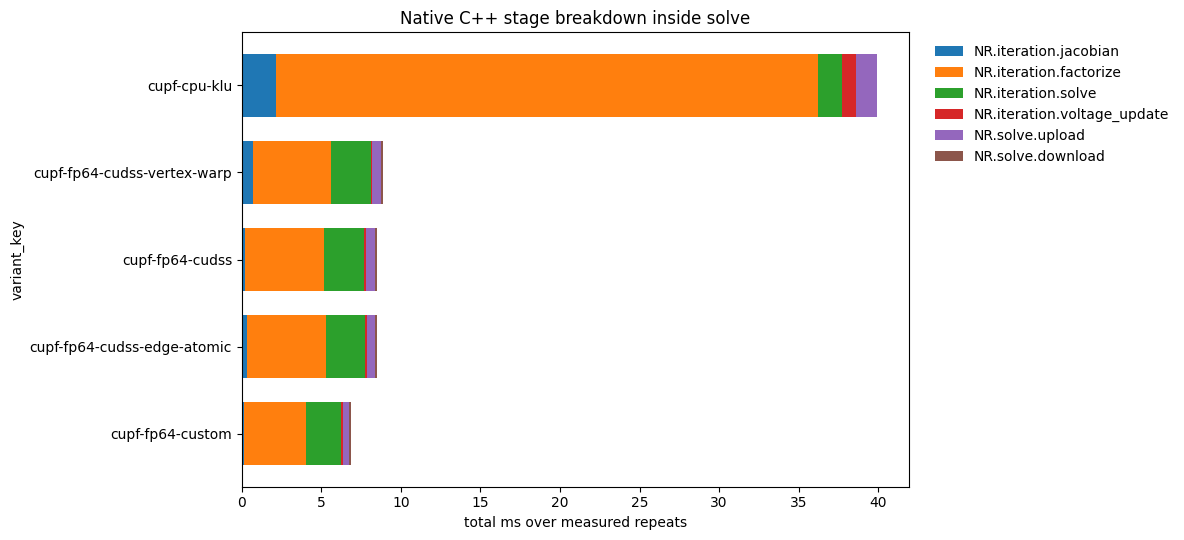

In [9]:
timer_names = [
    'NR.iteration.jacobian',
    'NR.iteration.factorize',
    'NR.iteration.solve',
    'NR.iteration.voltage_update',
    'NR.solve.upload',
    'NR.solve.download',
]
stages = tu.native_stage_totals(run_dir, timer_names=timer_names)
stages['variant_key'] = stages['variant'].str.replace('-native', '', regex=False)
stage_table = stages.pivot_table(
    index='variant_key',
    columns='timer_name',
    values='total_ms',
    aggfunc='sum',
    fill_value=0.0,
)
stage_table = stage_table.reindex(phase_table['variant_key'])
display(stage_table.round(3))

plot_cols = [col for col in timer_names if col in stage_table.columns]
ax = stage_table[plot_cols].plot(kind='barh', stacked=True, figsize=(12, 5.5), width=0.72)
ax.set_xlabel('total ms over measured repeats')
ax.set_title('Native C++ stage breakdown inside solve')
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1.0), loc='upper left')
plt.tight_layout()

**결과 해석**

- CPU KLU는 `factorize`가 대부분을 차지한다. 04에서 본 CPU fixed-pattern Jacobian은 Jacobian 구조 비용을 줄이지만, 큰 케이스에서는 sparse factorization이 여전히 큰 항으로 남는다.
- cuDSS/custom GPU path는 `jacobian` stage 자체보다 `factorize`와 `solve` stage가 더 중요하다. Edge/EdgeAtomic/VertexWarp의 전체 solve 차이가 작게 보이면, Jacobian fill 방식보다 linear solve 쪽이 지배적이라는 해석이 자연스럽다.
- `initialize_ms`는 단일 solve latency에서는 크게 보일 수 있다. 같은 topology를 여러 scenario에 재사용하는 batch/time-series 문제에서는 이 비용을 한 번 내고 여러 solve로 나누어 생각해야 한다.
- custom solver가 cuDSS보다 짧게 나오면, 다음 연구 방향은 Jacobian kernel 미세 조정보다 sparse linear solver의 구조를 power-flow Jacobian에 맞추는 쪽이다.

**정리**

- GPU path도 Newton-Raphson 수식은 바꾸지 않는다. 바뀌는 것은 Jacobian fill과 `J dx = mismatch` solve의 구현 위치다.
- `Edge`, `EdgeAtomic`, `VertexWarp`는 같은 reduced Jacobian 값을 다른 parallel layout으로 채운다.
- cuDSS는 symbolic analysis, numeric factorization/refactorization, solve phase로 나뉜다.
- GPU의 내부 병목은 native C++ timer로 판단해야 한다. pybind end-to-end time은 API latency를 볼 때 따로 사용한다.
- `case6468rte`에서는 CPU KLU와 GPU solver의 차이가 Jacobian fill보다 factorization/solve stage에서 더 크게 나타난다.

다음 장에서는 이 single-case solve 관점에서 벗어나, 같은 topology를 여러 입력 조건에 반복 적용하는 batch solve와 Python/Torch interface를 본다.